# MCDIA503 - Exploración Inteligente para la Ciencia de Datos
## Evaluación Sumativa 2 - Avance del proyecto Fases 2 y 3

**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Curso:** 202681.2538 | Exploración Inteligente de Datos  
**Dataset:** Titanic distribuido por Seaborn (copia local reproducible)  
**Fecha:** 15/09/2026

### I. Encabezado e identificación del notebook

**Foco:** preparar analíticamente Titanic y explorar, de forma descriptiva y no causal, cómo se relaciona la supervivencia con sexo, clase, edad, tarifa y contexto familiar. El flujo conecta diagnóstico, limpieza, integración, transformaciones, análisis univariado/bivariado y anomalías.

## II. Carga del dataset y descripción inicial
Se prepara el entorno, se localiza el archivo local y se registra SHA-256. El notebook reconoce tanto el esquema Seaborn como el esquema clásico Kaggle para mantener reproducibilidad.

In [1]:
from pathlib import Path
import hashlib, json, platform
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=220; plt.rcParams["axes.titleweight"]="bold"
cwd=Path.cwd().resolve(); roots=[cwd,cwd.parent,cwd.parent.parent]; PROJECT_ROOT=next((p for p in roots if (p/"data/input").exists()),cwd)
INPUT_DIR=PROJECT_ROOT/"data/input"; PROCESS_DIR=PROJECT_ROOT/"data/process"; FIGURES_DIR=PROJECT_ROOT/"figures"; OUTPUTS_DIR=PROJECT_ROOT/"outputs"
for d in [PROCESS_DIR,FIGURES_DIR,OUTPUTS_DIR]: d.mkdir(parents=True,exist_ok=True)
DATA_PATH=next((p for p in [INPUT_DIR/"titanic.csv",INPUT_DIR/"Titanic.csv"] if p.exists()),None)
if DATA_PATH is None: raise FileNotFoundError("Falta data/input/titanic.csv")
raw=pd.read_csv(DATA_PATH)
sea={'survived','pclass','sex','age','sibsp','parch','fare','embarked','class','who','adult_male','deck','embark_town','alive','alone'}; kag={'Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Cabin'}
if sea.issubset(raw.columns):
    titanic=raw[['survived','pclass','sex','age','sibsp','parch','fare','embarked','class','who','adult_male','deck','embark_town','alive','alone']].copy(); schema='Seaborn'
elif kag.issubset(raw.columns):
    titanic=pd.DataFrame({'survived':raw.Survived.astype(int),'pclass':raw.Pclass.astype(int),'sex':raw.Sex.str.lower(),'age':raw.Age,'sibsp':raw.SibSp.astype(int),'parch':raw.Parch.astype(int),'fare':raw.Fare,'embarked':raw.Embarked}); titanic['class']=titanic.pclass.map({1:'First',2:'Second',3:'Third'}); titanic['who']=np.where(titanic.age.lt(16),'child',titanic.sex); titanic['adult_male']=titanic.sex.eq('male')&titanic.age.ge(16); titanic['deck']=raw.Cabin.astype('string').str.strip().str[0]; titanic['embark_town']=titanic.embarked.map({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'}); titanic['alive']=titanic.survived.map({0:'no',1:'yes'}); titanic['alone']=(titanic.sibsp+titanic.parch).eq(0); schema='Kaggle convertido a Seaborn'
else: raise ValueError("Esquema Titanic no reconocido")
sha=hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(); print('Archivo:',DATA_PATH.relative_to(PROJECT_ROOT)); print('Esquema:',schema); print('SHA-256:',sha); print('Dimensiones:',titanic.shape); display(titanic.head())

Archivo: data\input\titanic.csv
Esquema: Seaborn
SHA-256: 43af81a01f25a7771c9a42809a31625f4d0de3f335cdf29961f9ba179a86c13d
Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## III. Revisión inicial del contenido del dataset
La unidad de análisis es un pasajero. Se inspeccionan tipos, cardinalidad, faltantes y categorías para definir reglas de preparación y visualización.

In [2]:
review=pd.DataFrame({'dtype':titanic.dtypes.astype(str),'n_unicos':titanic.nunique(dropna=True),'n_missing':titanic.isna().sum(),'pct_missing':(titanic.isna().mean()*100).round(2)}); display(review); print('Columnas:',list(titanic.columns))
for col in ['survived','pclass','sex','embarked','class','who','deck','alive','alone']: print(col, list(pd.Series(titanic[col].dropna().unique()).astype(str))[:12])

,dtype,n_unicos,n_missing,pct_missing
survived,int64,2,0,0.00
pclass,int64,3,0,0.00
sex,object,2,0,0.00
age,float64,88,177,19.87
sibsp,int64,7,0,0.00
parch,int64,7,0,0.00
fare,float64,248,0,0.00
embarked,object,3,2,0.22
class,object,3,0,0.00
who,object,3,0,0.00


Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived ['0', '1']
pclass ['3', '1', '2']
sex ['male', 'female']
embarked ['S', 'C', 'Q']
class ['Third', 'First', 'Second']
who ['man', 'woman', 'child']
deck ['C', 'E', 'G', 'D', 'A', 'B', 'F']
alive ['no', 'yes']
alone ['False', 'True']


## IV. Diagnóstico de calidad de datos
Se revisan completitud, duplicados, validez, consistencia y valores extremos. Los problemas se priorizan por impacto analítico: alta (variable central), media (requiere tratamiento documentado) y baja (validar/documentar).

Duplicados: 107


,n_missing,pct_missing
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


,cumple
survived_en_0_1,True
pclass_en_1_2_3,True
sex_valido,True
age_no_negativa,True
fare_no_negativa,True
class_coherente_pclass,True
alive_coherente_survived,True
embark_town_coherente,True
alone_coherente,True


,campo,regla,diagnostico,prioridad,accion
0,age,Completitud,"177 faltantes (~19,9%)",Alta,Imputar mediana por sex x class en variable nu...
1,deck,Completitud,"687 faltantes (~77,1%)",Media,No adivinar; usar Unknown + indicador
2,embarked / embark_town,Completitud,"2 faltantes (~0,2%)",Media,Completar con moda manteniendo coherencia
3,filas,Unicidad,107 duplicadas,Baja,No eliminar
4,age / fare,Validez,Extremos estadísticos pero rangos plausibles,Media,Investigar antes de eliminar


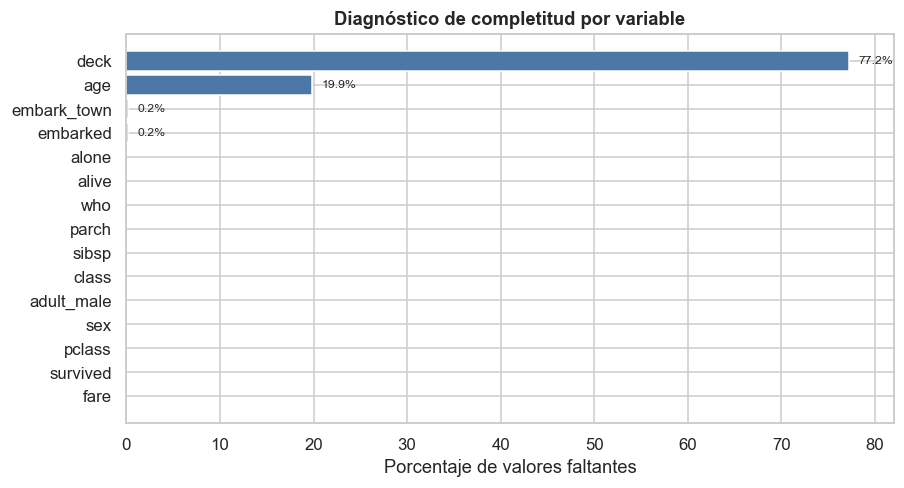

In [3]:
missing=pd.DataFrame({'n_missing':titanic.isna().sum(),'pct_missing':(titanic.isna().mean()*100).round(2)}).sort_values('pct_missing',ascending=False); dups=int(titanic.duplicated().sum())
checks={'survived_en_0_1':titanic.survived.isin([0,1]).all(),'pclass_en_1_2_3':titanic.pclass.isin([1,2,3]).all(),'sex_valido':titanic.sex.isin(['male','female']).all(),'age_no_negativa':titanic.age.dropna().ge(0).all(),'fare_no_negativa':titanic.fare.ge(0).all(),'class_coherente_pclass':(titanic['class'].astype(str)==titanic.pclass.map({1:'First',2:'Second',3:'Third'})).all(),'alive_coherente_survived':(titanic.alive.astype(str)==titanic.survived.map({0:'no',1:'yes'})).all(),'embark_town_coherente':(titanic.embark_town.fillna('<NA>').astype(str)==titanic.embarked.map({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'}).fillna('<NA>').astype(str)).all(),'alone_coherente':(titanic.alone.astype(bool)==(titanic.sibsp+titanic.parch).eq(0)).all()}
rules=pd.DataFrame([['age','Completitud','177 faltantes (~19,9%)','Alta','Imputar mediana por sex x class en variable nueva + bandera'],['deck','Completitud','687 faltantes (~77,1%)','Media','No adivinar; usar Unknown + indicador'],['embarked / embark_town','Completitud','2 faltantes (~0,2%)','Media','Completar con moda manteniendo coherencia'],['filas','Unicidad',f'{dups} duplicadas','Baja','No eliminar'],['age / fare','Validez','Extremos estadísticos pero rangos plausibles','Media','Investigar antes de eliminar']],columns=['campo','regla','diagnostico','prioridad','accion'])
print('Duplicados:',dups); display(missing); display(pd.Series(checks,name='cumple').to_frame()); display(rules); missing.to_csv(OUTPUTS_DIR/'diagnostico_missing.csv'); rules.to_csv(OUTPUTS_DIR/'matriz_reglas_calidad.csv',index=False)
fig,ax=plt.subplots(figsize=(8.4,4.6)); pm=missing.sort_values('pct_missing'); ax.barh(pm.index,pm.pct_missing,color='#4C78A8'); ax.set(xlabel='Porcentaje de valores faltantes',ylabel='',title='Diagnóstico de completitud por variable',xlim=(0,82)); [ax.text(v+1,i,f'{v:.1f}%',va='center',fontsize=8) for i,v in enumerate(pm.pct_missing) if v>0]; fig.tight_layout(); fig.savefig(FIGURES_DIR/'01_diagnostico_missing.png',bbox_inches='tight'); plt.show()

**Lectura.** `deck` concentra la mayor ausencia y no es defendible imputar una cubierta específica. `age` tiene cerca de 20 % de faltantes y sí es relevante para el foco, por lo que requiere tratamiento explícito. Los dos faltantes de embarque tienen impacto acotado. No hay filas idénticas ni rangos numéricos imposibles.

## V. Limpieza, validación e integración
Se aplica limpieza conservadora: `age_clean` se imputa con la mediana dentro de `sex × class` y se marca `age_imputed`; `embarked`/`embark_town` se completan con la moda; `deck` se recodifica como `Unknown` y se conserva `deck_known`. Los outliers se investigan, no se eliminan automáticamente.

**Integración controlada.** Al existir una sola fuente, se aplica el ejercicio de tablas derivadas: core + contexto, unidas por `row_id` con `validate="one_to_one"`, verificando filas, unicidad y coincidencias.

In [4]:
work=titanic.copy().reset_index(drop=True); work.insert(0,'row_id',np.arange(1,len(work)+1)); work['age_imputed']=work.age.isna(); gm=work.groupby(['sex','class'],dropna=False).age.transform('median'); work['age_clean']=work.age.fillna(gm).fillna(work.age.median()); mode=work.embarked.mode().iat[0]; work['embarked_clean']=work.embarked.fillna(mode); work['embark_town_clean']=work.embarked_clean.map({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'}); work['deck_known']=work.deck.notna(); work['deck_clean']=work.deck.astype('string').fillna('Unknown'); work['who_clean']=np.where(work.age_clean.lt(16),'child',work.sex); work['adult_male_clean']=work.sex.eq('male')&work.age_clean.ge(16)
core=work[['row_id','survived','pclass','sex','age_clean','age_imputed','fare']].copy(); context=work[['row_id','class','embarked_clean','embark_town_clean','deck_clean','deck_known','sibsp','parch','alone','who_clean','adult_male_clean']].copy(); merged=core.merge(context,on='row_id',how='left',validate='one_to_one',indicator=True); val=pd.DataFrame({'metrica':['filas_core','filas_context','filas_merged','claves_core_unicas','claves_context_unicas','coincidencias_both','left_only'],'valor':[len(core),len(context),len(merged),core.row_id.is_unique,context.row_id.is_unique,int((merged._merge=='both').sum()),int((merged._merge=='left_only').sum())]}); display(val); assert len(merged)==891 and (merged._merge=='both').all(); merged=merged.drop(columns='_merge'); val.to_csv(OUTPUTS_DIR/'validacion_integracion.csv',index=False); display(pd.DataFrame({'variable':['age_clean','embarked_clean','embark_town_clean','deck_clean'],'missing_post':[merged[c].isna().sum() for c in ['age_clean','embarked_clean','embark_town_clean','deck_clean']]}))

,metrica,valor
0,filas_core,891
1,filas_context,891
2,filas_merged,891
3,claves_core_unicas,True
4,claves_context_unicas,True
5,coincidencias_both,891
6,left_only,0


,variable,missing_post
0,age_clean,0
1,embarked_clean,0
2,embark_town_clean,0
3,deck_clean,0


La integración conserva las 891 observaciones, todas las claves coinciden y no hay multiplicación ni pérdida de filas; se mantiene la granularidad de un pasajero por registro.

## VI. Transformaciones aplicadas y preparación del dataset
Se crean `family_size`, `family_group`, `age_group` y `fare_log1p`; se ordenan las categorías y se exporta la versión preparada a `data/process/titanic_f23_prepared.csv`.

In [5]:
prepared=merged.copy(); prepared['family_size']=prepared.sibsp+prepared.parch+1; prepared['family_group']=pd.cut(prepared.family_size,[0,1,4,np.inf],labels=['Solo','Pequeña (2-4)','Grande (5+)'],include_lowest=True); prepared['age_group']=pd.cut(prepared.age_clean,[0,16,35,60,np.inf],right=False,labels=['Niño (<16)','Joven (16-34)','Adulto (35-59)','Mayor (60+)']); prepared['fare_log1p']=np.log1p(prepared.fare); prepared['class']=pd.Categorical(prepared['class'],['First','Second','Third'],ordered=True); prepared['family_group']=pd.Categorical(prepared.family_group,['Solo','Pequeña (2-4)','Grande (5+)'],ordered=True); prepared.to_csv(PROCESS_DIR/'titanic_f23_prepared.csv',index=False); print('Dataset preparado:',prepared.shape); display(prepared.head()); display(prepared[['survived','pclass','sex','age_clean','fare','embarked_clean','class','family_size','family_group']].isna().sum().to_frame('missing'))

Dataset preparado: (891, 21)


,row_id,survived,pclass,sex,age_clean,age_imputed,fare,class,embarked_clean,embark_town_clean,...,deck_known,sibsp,parch,alone,who_clean,adult_male_clean,family_size,family_group,age_group,fare_log1p
0,1,0,3,male,22.0,False,7.2500,Third,S,Southampton,...,False,1,0,False,male,True,2,Pequeña (2-4),Joven (16-34),2.110213
1,2,1,1,female,38.0,False,71.2833,First,C,Cherbourg,...,True,1,0,False,female,False,2,Pequeña (2-4),Adulto (35-59),4.280593
2,3,1,3,female,26.0,False,7.9250,Third,S,Southampton,...,False,0,0,True,female,False,1,Solo,Joven (16-34),2.188856
3,4,1,1,female,35.0,False,53.1000,First,S,Southampton,...,True,1,0,False,female,False,2,Pequeña (2-4),Adulto (35-59),3.990834
4,5,0,3,male,35.0,False,8.0500,Third,S,Southampton,...,False,0,0,True,male,True,1,Solo,Adulto (35-59),2.202765


,missing
survived,0
pclass,0
sex,0
age_clean,0
fare,0
embarked_clean,0
class,0
family_size,0
family_group,0


## VII. Análisis univariado
Se combinan media, mediana, cuartiles e IQR con histogramas y boxplots. La mediana y el IQR son especialmente relevantes en distribuciones asimétricas.

,n,media,mediana,std,q1,q3,IQR,min,max
age_clean,891.0,29.112,26.000,13.304,21.50,36.0,14.50,0.42,80.000
fare,891.0,32.204,14.454,49.693,7.91,31.0,23.09,0.00,512.329
family_size,891.0,1.905,1.000,1.613,1.00,2.0,1.00,1.00,11.000


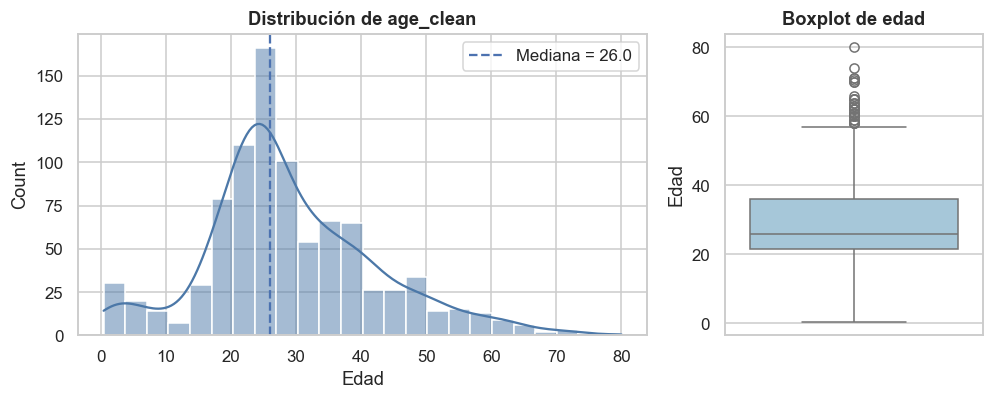

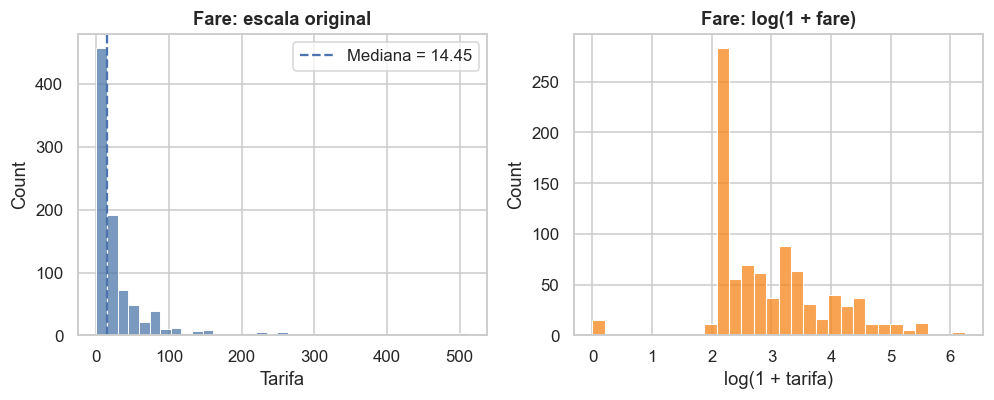

In [6]:
def summ(s):
 s=pd.Series(s).dropna().astype(float); return pd.Series({'n':len(s),'media':s.mean(),'mediana':s.median(),'std':s.std(),'q1':s.quantile(.25),'q3':s.quantile(.75),'IQR':s.quantile(.75)-s.quantile(.25),'min':s.min(),'max':s.max()})
desc=pd.DataFrame({'age_clean':summ(prepared.age_clean),'fare':summ(prepared.fare),'family_size':summ(prepared.family_size)}).T.round(3); display(desc); desc.to_csv(OUTPUTS_DIR/'descriptivos_numericos.csv')
fig,axs=plt.subplots(1,2,figsize=(9.2,3.8),gridspec_kw={'width_ratios':[2.2,1]}); sns.histplot(prepared.age_clean,bins=24,kde=True,color='#4C78A8',ax=axs[0]); axs[0].axvline(prepared.age_clean.median(),ls='--',label=f'Mediana = {prepared.age_clean.median():.1f}'); axs[0].set(title='Distribución de age_clean',xlabel='Edad'); axs[0].legend(); sns.boxplot(y=prepared.age_clean,color='#9ECAE1',ax=axs[1]); axs[1].set(title='Boxplot de edad',ylabel='Edad'); fig.tight_layout(); fig.savefig(FIGURES_DIR/'02_univariado_age.png',bbox_inches='tight'); plt.show()
fig,axs=plt.subplots(1,2,figsize=(9.2,3.8)); sns.histplot(prepared.fare,bins=35,color='#4C78A8',ax=axs[0]); axs[0].axvline(prepared.fare.median(),ls='--',label=f'Mediana = {prepared.fare.median():.2f}'); axs[0].set(title='Fare: escala original',xlabel='Tarifa'); axs[0].legend(); sns.histplot(prepared.fare_log1p,bins=30,color='#F58518',ax=axs[1]); axs[1].set(title='Fare: log(1 + fare)',xlabel='log(1 + tarifa)'); fig.tight_layout(); fig.savefig(FIGURES_DIR/'03_univariado_fare.png',bbox_inches='tight'); plt.show()

### Interpretación CER - análisis univariado

**Claim (afirmación).** La variable `fare` presenta una distribución fuertemente asimétrica a la derecha; por ello, la mediana y el IQR son resúmenes más representativos que la media para describir el valor típico y la dispersión central.

**Evidence (evidencia).** La tarifa tiene mediana 14,45, media 32,20 e IQR 23,09. El histograma muestra concentración en valores bajos y una cola derecha extensa; el boxplot identifica numerosos valores extremos. `age_clean`, en cambio, presenta mediana 26 años e IQR 14,5.

**Reasoning (razonamiento).** La media superior a la mediana y la cola derecha son consistentes con una distribución sesgada por un conjunto reducido de tarifas altas. En este contexto, medidas robustas como mediana e IQR reducen la influencia de esos extremos sin eliminarlos ni perder información analítica. La transformación `log1p(fare)` se utiliza solo como apoyo visual y no reemplaza el valor original.


## VIII. Análisis bivariado
Se examinan diferencias descriptivas de supervivencia por sexo, clase y grupo familiar, además de distribuciones de edad y tarifa según supervivencia. Asociación no implica causalidad.

,n,sobrevivientes,tasa,tasa_pct
sex,,,,
female,314,233,0.742038,74.2
male,577,109,0.188908,18.9


,n,sobrevivientes,tasa,tasa_pct
class,,,,
First,216,136,0.629630,63.0
Second,184,87,0.472826,47.3
Third,491,119,0.242363,24.2


class,First,Second,Third
sex,,,
female,96.8,92.1,50.0
male,36.9,15.7,13.5


,n,sobrevivientes,tasa,tasa_pct
family_group,,,,
Solo,537,163,0.303538,30.4
Pequeña (2-4),292,169,0.578767,57.9
Grande (5+),62,10,0.161290,16.1


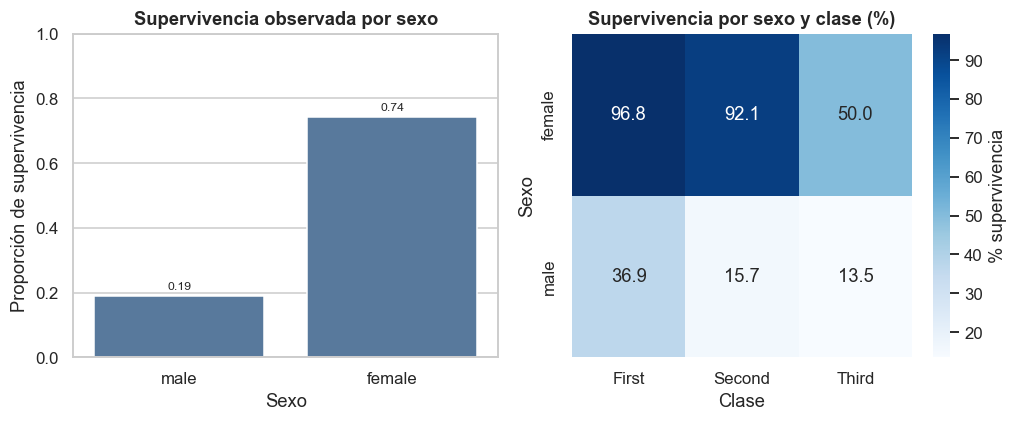

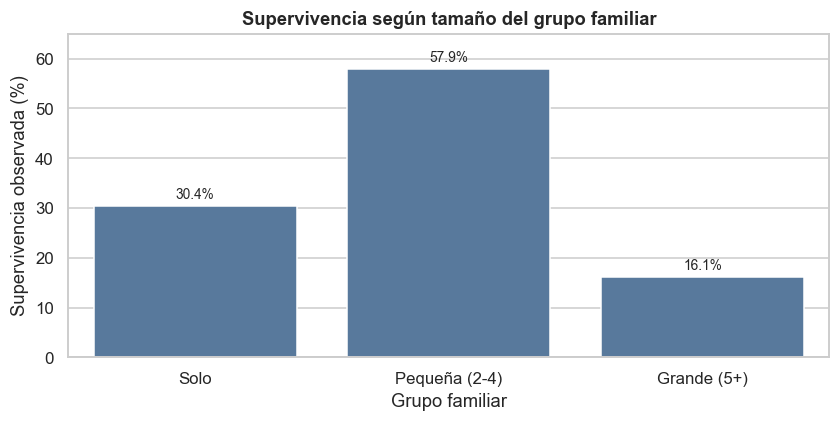

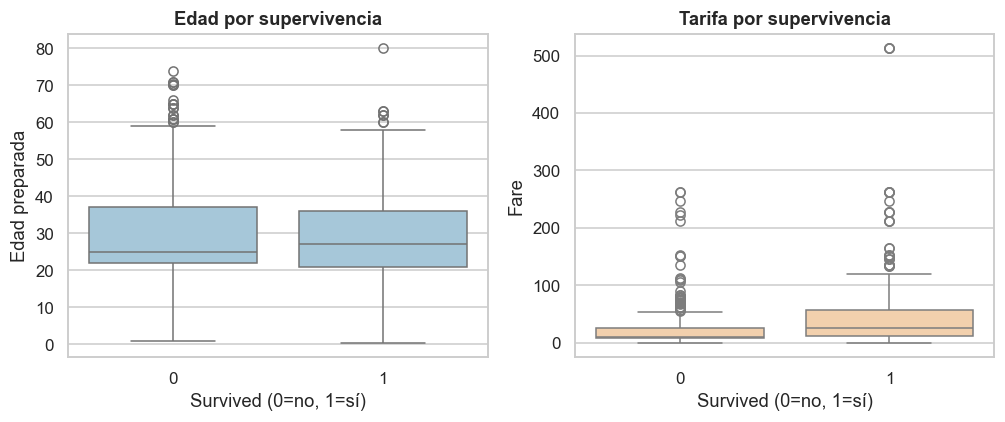

In [7]:
sex=prepared.groupby('sex',observed=False).survived.agg(n='count',sobrevivientes='sum',tasa='mean'); sex['tasa_pct']=(sex.tasa*100).round(1); cl=prepared.groupby('class',observed=False).survived.agg(n='count',sobrevivientes='sum',tasa='mean'); cl['tasa_pct']=(cl.tasa*100).round(1); sc=prepared.pivot_table(index='sex',columns='class',values='survived',aggfunc='mean',observed=False)*100; fam=prepared.groupby('family_group',observed=False).survived.agg(n='count',sobrevivientes='sum',tasa='mean'); fam['tasa_pct']=(fam.tasa*100).round(1); display(sex); display(cl); display(sc.round(1)); display(fam); sex.to_csv(OUTPUTS_DIR/'supervivencia_por_sexo.csv'); cl.to_csv(OUTPUTS_DIR/'supervivencia_por_clase.csv'); fam.to_csv(OUTPUTS_DIR/'supervivencia_por_grupo_familiar.csv'); sc.round(2).to_csv(OUTPUTS_DIR/'supervivencia_sexo_clase.csv')
fig,axs=plt.subplots(1,2,figsize=(9.5,4.0)); sns.barplot(data=prepared,x='sex',y='survived',estimator='mean',errorbar=None,color='#4C78A8',ax=axs[0]); axs[0].set(ylim=(0,1),ylabel='Proporción de supervivencia',xlabel='Sexo',title='Supervivencia observada por sexo'); [axs[0].bar_label(c,fmt='%.2f',padding=3,fontsize=8) for c in axs[0].containers]; sns.heatmap(sc.round(1),annot=True,fmt='.1f',cmap='Blues',cbar_kws={'label':'% supervivencia'},ax=axs[1]); axs[1].set(title='Supervivencia por sexo y clase (%)',xlabel='Clase',ylabel='Sexo'); fig.tight_layout(); fig.savefig(FIGURES_DIR/'04_bivariado_sexo_clase.png',bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(7.8,4)); pf=fam.reset_index(); sns.barplot(data=pf,x='family_group',y='tasa_pct',errorbar=None,color='#4C78A8',ax=ax); ax.set(ylim=(0,65),ylabel='Supervivencia observada (%)',xlabel='Grupo familiar',title='Supervivencia según tamaño del grupo familiar'); [ax.bar_label(c,fmt='%.1f%%',padding=3,fontsize=9) for c in ax.containers]; fig.tight_layout(); fig.savefig(FIGURES_DIR/'05_bivariado_familia.png',bbox_inches='tight'); plt.show()
fig,axs=plt.subplots(1,2,figsize=(9.3,4)); sns.boxplot(data=prepared,x='survived',y='age_clean',color='#9ECAE1',ax=axs[0]); axs[0].set(title='Edad por supervivencia',xlabel='Survived (0=no, 1=sí)',ylabel='Edad preparada'); sns.boxplot(data=prepared,x='survived',y='fare',color='#FDD0A2',ax=axs[1]); axs[1].set(title='Tarifa por supervivencia',xlabel='Survived (0=no, 1=sí)',ylabel='Fare'); fig.tight_layout(); fig.savefig(FIGURES_DIR/'06_bivariado_edad_fare.png',bbox_inches='tight'); plt.show()

### Interpretación CER - análisis bivariado

**CER 1 - Sexo y clase**
- **Claim:** la supervivencia observada difiere de forma marcada por sexo y clase.
- **Evidence:** 74,2 % de las mujeres sobrevivió frente a 18,9 % de los hombres; por clase, las tasas fueron 63,0 % (primera), 47,3 % (segunda) y 24,2 % (tercera). El cruce `sex × class` mantiene diferencias visibles entre los estratos.
- **Reasoning:** la persistencia de las diferencias en las comparaciones y en el heatmap respalda una asociación descriptiva entre estas variables y la supervivencia. El resultado no se interpreta como causal, porque el dataset es observacional.

**CER 2 - Contexto familiar**
- **Claim:** la relación entre tamaño del grupo familiar y supervivencia no es lineal.
- **Evidence:** la supervivencia observada es 57,9 % en grupos pequeños (2-4), 30,4 % en quienes viajan solos y 16,1 % en grupos grandes (5+).
- **Reasoning:** el máximo se concentra en el grupo intermedio y disminuye en ambos extremos, por lo que no corresponde resumir la relación como 'a mayor familia, mayor supervivencia'. El patrón debe entenderse como una diferencia descriptiva entre grupos.


## IX. Patrones, anomalías y hallazgos iniciales
Los outliers se detectan con 1,5 × IQR y luego se contrastan con plausibilidad. Un extremo estadístico no se elimina por defecto.

,variable,q1,q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers,min,max
0,age_clean,21.50,36.0,14.50,-0.250,57.750,33,3.704,0.42,80.000
1,fare,7.91,31.0,23.09,-26.724,65.634,116,13.019,0.00,512.329


Fare = 0: 15


,row_id,pclass,sex,fare,survived,family_size
258,259,1,female,512.3292,1,1
737,738,1,male,512.3292,1,1
679,680,1,male,512.3292,1,2
27,28,1,male,263.0000,0,6
341,342,1,female,263.0000,1,6
438,439,1,male,263.0000,0,6
88,89,1,female,263.0000,1,6
311,312,1,female,262.3750,1,5
742,743,1,female,262.3750,1,5
299,300,1,female,247.5208,1,2


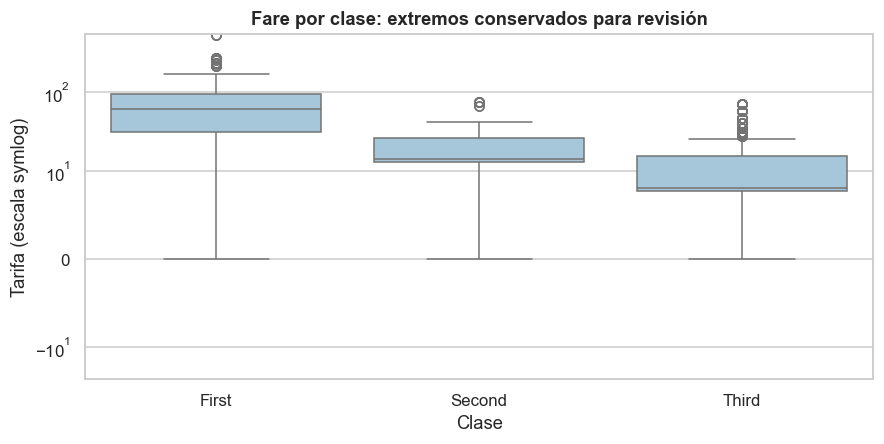

In [8]:
def oq(df,col):
 s=df[col].dropna().astype(float); q1,q3=s.quantile(.25),s.quantile(.75); i=q3-q1; lo,hi=q1-1.5*i,q3+1.5*i; m=(df[col]<lo)|(df[col]>hi); return {'variable':col,'q1':q1,'q3':q3,'IQR':i,'lim_inf':lo,'lim_sup':hi,'n_outliers':int(m.sum()),'pct_outliers':m.mean()*100,'min':s.min(),'max':s.max()},m
a,am=oq(prepared,'age_clean'); f,fm=oq(prepared,'fare'); out=pd.DataFrame([a,f]).round(3); display(out); print('Fare = 0:',int(prepared.fare.eq(0).sum())); display(prepared.loc[fm,['row_id','pclass','sex','fare','survived','family_size']].sort_values('fare',ascending=False).head(12)); out.to_csv(OUTPUTS_DIR/'resumen_outliers_iqr.csv',index=False)
fig,ax=plt.subplots(figsize=(8.2,4.2)); sns.boxplot(data=prepared,x='class',y='fare',color='#9ECAE1',ax=ax); ax.set_yscale('symlog',linthresh=10); ax.set(title='Fare por clase: extremos conservados para revisión',xlabel='Clase',ylabel='Tarifa (escala symlog)'); fig.tight_layout(); fig.savefig(FIGURES_DIR/'07_outliers_fare_clase.png',bbox_inches='tight'); plt.show()

### Interpretación CER - patrones, anomalías y outliers

**Claim (afirmación).** Los valores extremos detectados en `fare` y `age_clean` son, en su mayoría, casos plausibles que aportan estructura al fenómeno y no errores evidentes de calidad.

**Evidence (evidencia).** La regla de 1,5 × IQR identifica 116 extremos en `fare` (13,0 %) y 33 en `age_clean` (3,7 %). Las tarifas son no negativas, las edades permanecen en rangos humanos plausibles y los valores altos de tarifa se concentran especialmente en clases de mayor precio.

**Reasoning (razonamiento).** Un outlier estadístico indica distancia respecto de la distribución, no invalidez del registro. Como los casos extremos respetan las reglas de validez y son coherentes con el contexto del dataset, se conservan y documentan. Se eliminarían solo si existiera evidencia de error de captura, formato o imposibilidad lógica. `deck`, por otra parte, se mantiene como `Unknown` porque su 77,1 % de ausencia no permite reconstruir una cubierta específica de forma defendible.


## X. Supuestos, límites y cierre del avance
La imputación de edad por mediana `sex × class` es una aproximación operativa y reduce parte de la variabilidad; no recupera el dato real. El dataset es histórico y observacional y no permite inferir causalidad. `fare` puede reflejar estructuras de ticket no modeladas. `alive` replica `survived`, por lo que debe excluirse de un futuro modelamiento para evitar leakage.

## XI. Cierre del avance
**Síntesis:** se obtuvo un dataset preparado, integrado y trazable, con reglas explícitas y evidencia intermedia.

**Principales hallazgos:** diferencias marcadas por sexo y clase, patrón familiar no lineal, tarifa muy asimétrica con extremos plausibles y ausencia severa en `deck`.

**Continuidad:** profundizar interacciones multivariadas y evaluar sensibilidad de resultados con y sin imputación de edad antes de cualquier modelamiento.

In [9]:
manifest={'input_file':str(DATA_PATH.relative_to(PROJECT_ROOT)),'input_sha256':sha,'rows':int(len(prepared)),'columns_prepared':int(prepared.shape[1]),'schema':schema,'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':plt.matplotlib.__version__,'seaborn':sns.__version__,'figures':sorted(p.name for p in FIGURES_DIR.glob('*.png'))}; (OUTPUTS_DIR/'manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8'); checklist={'Notebook ejecutado':True,'Diagnóstico completo':True,'Limpieza justificada':True,'Integración one-to-one validada':True,'Transformaciones documentadas':True,'Univariado con descriptivos y gráficos':True,'Bivariado con medidas y gráficos':True,'Outliers error vs señal':True,'Dataset preparado exportado':(PROCESS_DIR/'titanic_f23_prepared.csv').exists(),'7 figuras exportadas':len(list(FIGURES_DIR.glob('*.png')))>=7}; display(pd.Series(checklist,name='cumple').to_frame()); print('Proceso finalizado sin errores.')

,cumple
Notebook ejecutado,True
Diagnóstico completo,True
Limpieza justificada,True
Integración one-to-one validada,True
Transformaciones documentadas,True
Univariado con descriptivos y gráficos,True
Bivariado con medidas y gráficos,True
Outliers error vs señal,True
Dataset preparado exportado,True
7 figuras exportadas,True


Proceso finalizado sin errores.
